In [29]:
import torch
import torch.nn as nn

import numpy as np
import torch.nn.functional as F
from tqdm import tqdm
from torchvision.utils import save_image, make_grid


In [30]:
dataset_path = './datasets/mnist'

DEVICE = torch.device( "cpu")
batch_size = 32

latent_dim = 15

lr = 1e-3
num_epochs = 100

In [31]:
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

mnist_transform = transforms.Compose([
    transforms.ToTensor(), # [0, 255] -> [0, 1]
])

kwargs = {'num_workers': 1, 'pin_memory': True} if torch.cuda.is_available() else {}

train_dataset = MNIST(dataset_path, train=True, transform=mnist_transform, download=True)
test_dataset = MNIST(dataset_path, train=False, transform=mnist_transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, **kwargs)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, **kwargs)

canais_img = train_dataset[0][0].shape[0]
input_channels = canais_img
print(f'Número de canais da imagem: {canais_img}')

# Acessando o primeiro item do dataset
amostra_x, rotulo = train_dataset[0]

# Extraindo dimensões
canais = amostra_x.shape[0]
altura = amostra_x.shape[1]
largura = amostra_x.shape[2]
num_classes = 10

print(f"--- Info da Amostra ---")
print(f"Dimensões da Imagem: {canais} canais x {altura}px x {largura}px")
print(f"Rótulo (Label): {rotulo}") 

Número de canais da imagem: 1
--- Info da Amostra ---
Dimensões da Imagem: 1 canais x 28px x 28px
Rótulo (Label): 5


In [32]:
class Encoder(nn.Module):
    def __init__(self, input_channels, latent_dim, num_classes): # Adicionado num_classes
        super(Encoder, self).__init__()
        
        # O input_channels agora é original (1) + num_classes (10) = 11
        self.conv_layers = nn.Sequential(
            nn.Conv2d(input_channels + num_classes, 32, kernel_size=3, stride=2, padding=1), 
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Flatten() 
        )
        
        flat_features = 64 * 7 * 7 
        self.fc_mean = nn.Linear(flat_features, latent_dim)
        self.fc_logvar = nn.Linear(flat_features, latent_dim)

    def forward(self, x, y):
        # x: [batch, 1, 28, 28]
        # y: [batch, 10] (one-hot)
        
        # Expandimos o rótulo y para as dimensões da imagem [batch, 10, 28, 28]
        y_embedded = y.view(-1, 10, 1, 1).expand(-1, -1, x.size(2), x.size(3))
        
        # Concatenamos nos canais: entrada vira [batch, 11, 28, 28]
        x_cond = torch.cat([x, y_embedded], dim=1)
        
        h_ = self.conv_layers(x_cond)
        mean = self.fc_mean(h_)
        logvar = self.fc_logvar(h_)
        return mean, logvar

In [33]:
class Decoder(nn.Module):
    def __init__(self, latent_dim, output_channels, num_classes):
        super(Decoder, self).__init__()
        
        # A entrada agora é o vetor latente + o vetor da classe
        self.fc_upsample = nn.Linear(latent_dim + num_classes, 64 * 7 * 7)
        
        self.deconv_layers = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, output_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid() # Para MNIST entre [0, 1]
        )

    def forward(self, z, y):
        # z: [batch, latent_dim], y: [batch, 10]
        z_cond = torch.cat([z, y], dim=1) # Concatena vetores
        
        x = self.fc_upsample(z_cond)
        x = x.view(-1, 64, 7, 7) # Reshape para volume convolucional
        x = self.deconv_layers(x)
        return x

In [34]:
class Model(nn.Module):
    def __init__(self, Encoder, Decoder):
        super(Model, self).__init__()
        self.Encoder = Encoder
        self.Decoder = Decoder
    
    def reparameterize(self, mean, logvar):
        dp = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(dp).to(DEVICE)
        z = mean + dp * epsilon
        return z
    
    def forward(self, x, y):
        mean, logvar = self.Encoder(x, y)
        z = self.reparameterize(mean, logvar)
        x_hat = self.Decoder(z, y)
        return x_hat, mean, logvar
    

In [35]:
encoder = Encoder(input_channels, latent_dim, 10)
decoder = Decoder(latent_dim, input_channels, 10)
# import torchsummary as summary
model = Model(encoder, decoder).to(DEVICE)

# summary.summary(model, input_size=[(input_channels, 28, 28), (10, 1, 1)])


from torchinfo import summary

# 2. Definição dos tamanhos com o batch_size incluído
# Imagem: (Batch, Canais, Altura, Largura) -> (32, 1, 28, 28)
# Rótulo: (Batch, Classes) -> (32, 10)
input_shapes = [(batch_size, 1, 28, 28), (batch_size, 10)]

# 3. CHAMADA DO SUMMARY
# O dtypes garante que o modelo entenda que o label é um float (necessário para concatenação)
summary(model, input_size=input_shapes, dtypes=[torch.float, torch.float])

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [32, 1, 28, 28]           --
├─Encoder: 1-1                           [32, 15]                  --
│    └─Sequential: 2-1                   [32, 3136]                --
│    │    └─Conv2d: 3-1                  [32, 32, 14, 14]          3,200
│    │    └─LeakyReLU: 3-2               [32, 32, 14, 14]          --
│    │    └─Conv2d: 3-3                  [32, 64, 7, 7]            18,496
│    │    └─LeakyReLU: 3-4               [32, 64, 7, 7]            --
│    │    └─Flatten: 3-5                 [32, 3136]                --
│    └─Linear: 2-2                       [32, 15]                  47,055
│    └─Linear: 2-3                       [32, 15]                  47,055
├─Decoder: 1-2                           [32, 1, 28, 28]           --
│    └─Linear: 2-4                       [32, 3136]                81,536
│    └─Sequential: 2-5                   [32, 1, 28, 28]          

In [36]:
from torch.optim import Adam

# BCE_loss = nn.BCELoss()
# nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')

def loss_(x, x_hat, mean, logvar):
    reproduction_loss = -torch.sum(x * torch.log(x_hat + 1e-10) + (1 - x) * torch.log(1 - x_hat + 1e-10))
    DKL = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())
    return reproduction_loss + DKL

optimizer = Adam(model.parameters(), lr=lr)

In [37]:
print("Starting training VAE...")
model.train()

for epoch in range(num_epochs):
    overall_loss = 0
    for batch_idx, (x, rotulo) in enumerate(tqdm(train_loader)):
        x = x.view(-1, input_channels, altura, largura).to(DEVICE) # Garantindo que x tenha o formato correto para o Encoder
        y_cond = F.one_hot(rotulo, num_classes=10).float().to(DEVICE)
        optimizer.zero_grad()

        x_hat, mean, logvar = model(x, y_cond)

        if batch_idx == 0:
            print(f"--- Debug Batch 0 ---")
            # Exibe o número original (ex: 5)
            print(f"Rótulo Real (Classe): {rotulo[0].item()}")
            
            # Exibe o vetor One-Hot que foi para o modelo
            print(f"Vetor One-Hot (Condição): {y_cond[0].detach().cpu().numpy()}")
            
            # Exibe os parâmetros latentes
            print(f"Média (primeiros 5 valores): {mean[0][:5].detach().cpu().numpy()}")
            print(f"LogVar (primeiros 5 valores): {logvar[0][:5].detach().cpu().numpy()}")
            print(f"----------------------")

        loss = loss_(x, x_hat, mean, logvar)

        overall_loss += loss.item()
        loss.backward()
        optimizer.step()
    print("\tOverall Loss:", overall_loss, "\t(batch_idx+1): ", batch_idx+1, "\tBatch Size: ", batch_size)    
    print("\tEpoch", epoch + 1, "complete!", "\tAverage Loss: ", overall_loss / ((batch_idx+1)*batch_size))
print("Finish!!")

Starting training VAE...


  0%|          | 0/1875 [00:00<?, ?it/s]

--- Debug Batch 0 ---
Rótulo Real (Classe): 9
Vetor One-Hot (Condição): [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
Média (primeiros 5 valores): [-0.00494477  0.00104376  0.02408766 -0.03276328 -0.06884401]
LogVar (primeiros 5 valores): [-0.06329083  0.03061953  0.05477505 -0.01007481 -0.02167428]
----------------------


100%|██████████| 1875/1875 [00:49<00:00, 37.76it/s]


	Overall Loss: 7685024.849121094 	(batch_idx+1):  1875 	Batch Size:  32
	Epoch 1 complete! 	Average Loss:  128.08374748535155


...

	Overall Loss: 5633807.47265625 	(batch_idx+1):  1875 	Batch Size:  32
	Epoch 99 complete! 	Average Loss:  93.8967912109375


  0%|          | 4/1875 [00:00<00:56, 32.93it/s]

--- Debug Batch 0 ---
Rótulo Real (Classe): 9
Vetor One-Hot (Condição): [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
Média (primeiros 5 valores): [ 0.6546118  -0.36089838 -0.03673952 -0.3796649   0.14076671]
LogVar (primeiros 5 valores): [-1.3771228  -0.834095   -4.691509   -0.93321425 -1.2553905 ]
----------------------


100%|██████████| 1875/1875 [00:47<00:00, 39.46it/s]

	Overall Loss: 5633826.955322266 	(batch_idx+1):  1875 	Batch Size:  32
	Epoch 100 complete! 	Average Loss:  93.89711592203776
Finish!!


In [38]:

import matplotlib.pyplot as plt

In [39]:
model.eval()

with torch.no_grad():
    # 1. Capturamos o rótulo do test_loader
    for batch_idx, (x, rotulo) in enumerate(tqdm(test_loader)):
        
        # 2. Preparamos a imagem e o rótulo (One-Hot)
        x = x.view(-1, input_channels, altura, largura).to(DEVICE)
        y_cond = torch.nn.functional.one_hot(rotulo, num_classes=10).float().to(DEVICE)
        
        # 3. Passamos ambos para o modelo
        # No teste, geralmente só nos interessa o x_hat (reconstrução)
        x_hat, mean, logvar = model(x, y_cond)
        
        # O break está aqui para pegarmos apenas um batch para visualização posterior
        break

  0%|          | 0/313 [00:00<?, ?it/s]


In [40]:
def show_image(x, idx, labels=None):
    print(f"Shape original recebido: {x.shape}")
    
    x = x.detach().cpu()
    x = x.permute(0, 2, 3, 1)
    
    grid_size = int(np.sqrt(idx))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
    
    if idx == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i in range(idx):
        if i < len(x):
            img_to_show = x[i].numpy()
            
            if img_to_show.shape[-1] == 1:
                img_to_show = img_to_show.squeeze(-1)
                axes[i].imshow(img_to_show, cmap='gray')
            else:
                axes[i].imshow(img_to_show)
            
            # NOVIDADE: Se você passar os rótulos, eles aparecem em cima da imagem
            if labels is not None:
                # Se labels for one-hot, pegamos o índice do valor 1
                if len(labels.shape) > 1:
                    label_val = torch.argmax(labels[i]).item()
                else:
                    label_val = labels[i].item()
                axes[i].set_title(f"Label: {label_val}")
                
            axes[i].axis('off')
        else:
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

Shape original recebido: torch.Size([32, 1, 28, 28])


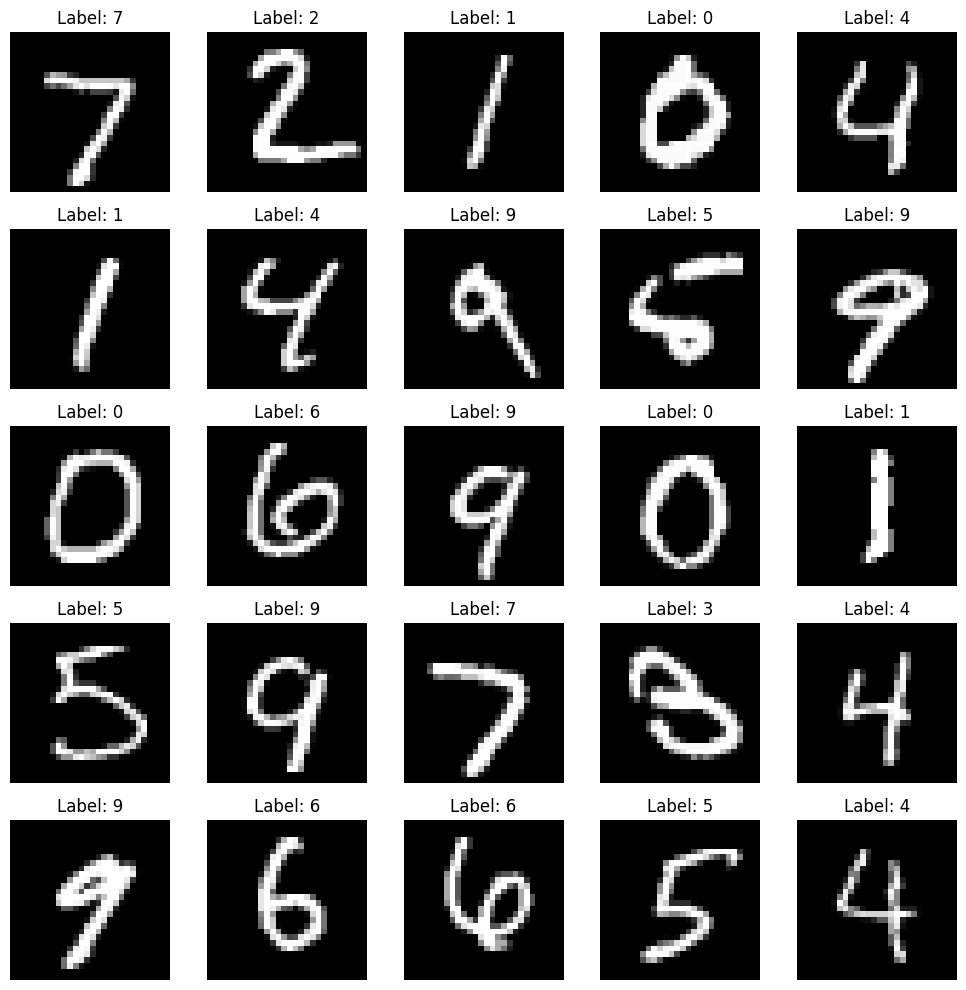

In [41]:
show_image(x, idx=25, labels=rotulo)

Shape original recebido: torch.Size([32, 1, 28, 28])


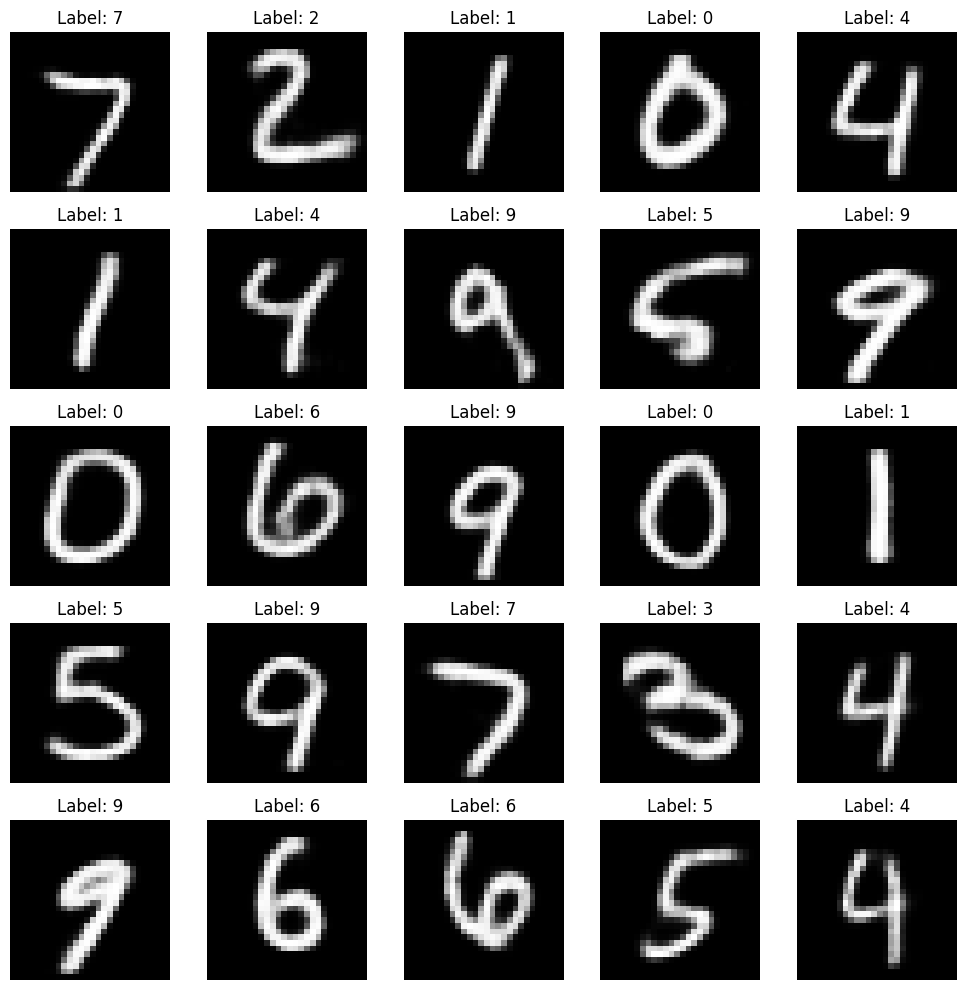

In [42]:
show_image(x_hat, idx=25, labels=rotulo)

  0%|          | 0/313 [00:00<?, ?it/s]


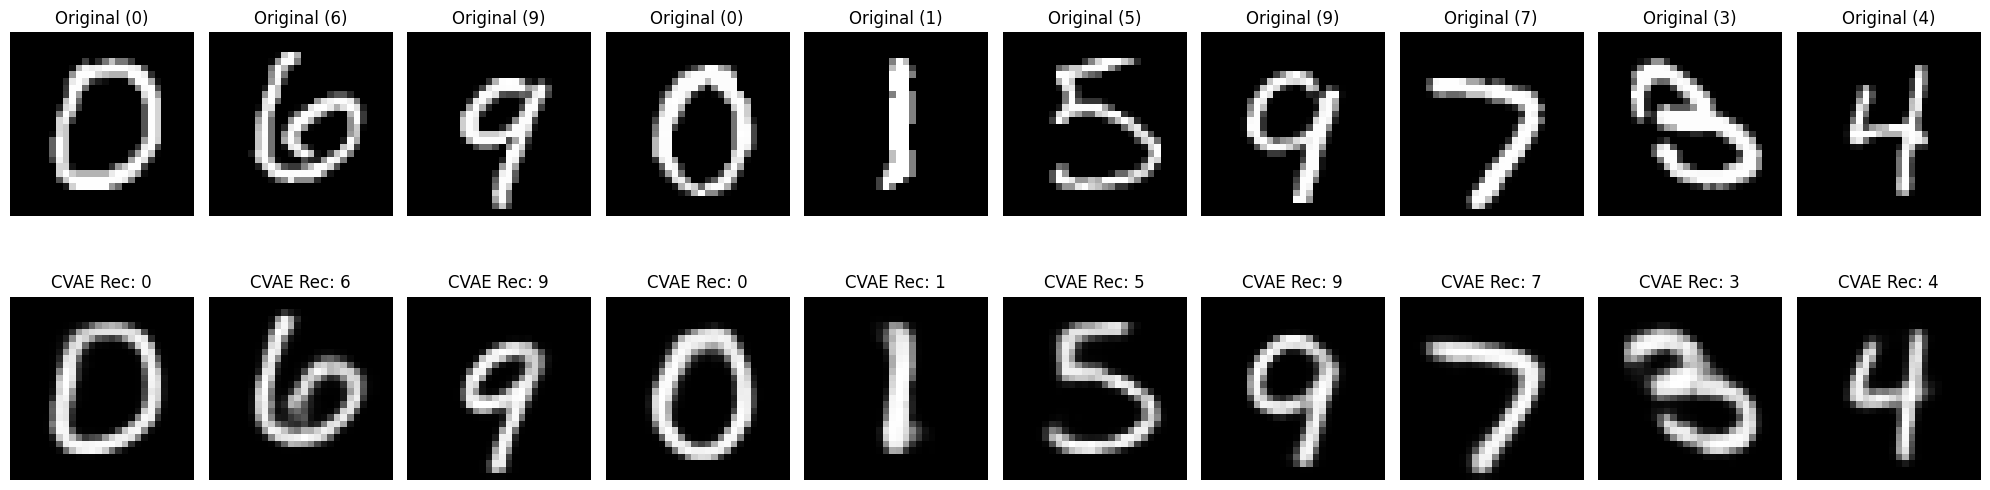

In [43]:
model.eval()
with torch.no_grad():
    # 1. Capturamos o rótulo do test_loader
    for batch_idx, (x, rotulo) in enumerate(tqdm(test_loader)):
        
        # 2. Preparamos a imagem e o rótulo (One-Hot)
        x = x.view(-1, input_channels, altura, largura).to(DEVICE)
        y_cond = torch.nn.functional.one_hot(rotulo, num_classes=10).float().to(DEVICE)
        
        # 3. Passamos ambos para o modelo
        # No teste, geralmente só nos interessa o x_hat (reconstrução)
        x_hat, mean, logvar = model(x, y_cond)
        
        # O break está aqui para pegarmos apenas um batch para visualização posterior
        break

n = 10 
plt.figure(figsize=(20, 6)) 

for i in range(n):
    # Pegamos o valor real do rótulo para colocar no título
    # Usamos i+10 para manter a lógica do seu índice original
    label_real = rotulo[i+10].item()

    # --- Imagem Original ---
    ax = plt.subplot(2, n, i + 1)
    img_original = x[i+10].cpu().permute(1, 2, 0)
    
    plt.imshow(img_original, cmap='gray')
    plt.title(f"Original ({label_real})") # Mostra o que a imagem REALMENTE é
    ax.axis('off')

    # --- Imagem Reconstruída ---
    ax = plt.subplot(2, n, i + 1 + n)
    img_reconstruida = x_hat[i+10].cpu().permute(1, 2, 0)
    
    plt.imshow(img_reconstruida, cmap='gray')
    # Mudamos o título de VAE para CVAE para ser condizente com o novo modelo
    plt.title(f"CVAE Rec: {label_real}") 
    ax.axis('off')

plt.tight_layout()
plt.show()

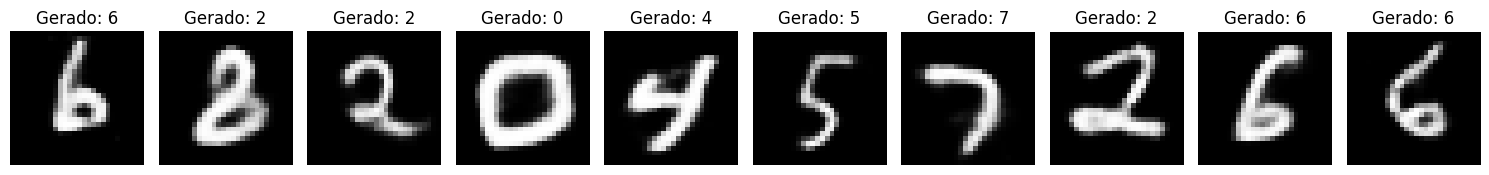

In [44]:
model.eval() # Garante que o modelo está em modo de inferência

n_geracoes = 10

with torch.no_grad():
    # 1. Criar 10 vetores latentes aleatórios (Distribuição Normal)
    z = torch.randn(n_geracoes, latent_dim).to(DEVICE)
    
    # 2. Criar 10 rótulos aleatórios entre 0 e 9
    rotulos_random = torch.randint(0, 10, (n_geracoes,)).to(DEVICE)
    
    # 3. Converter esses rótulos para One-Hot (formato que o Decoder espera)
    y_cond = torch.nn.functional.one_hot(rotulos_random, num_classes=10).float().to(DEVICE)
    
    # 4. Passar para o Decoder (repare que não usamos o Encoder aqui, pois estamos GERANDO)
    # No CVAE, o decoder recebe o ruído E a condição
    novas_imagens = model.Decoder(z, y_cond)

# --- Visualização ---
plt.figure(figsize=(15, 4))
for i in range(n_geracoes):
    ax = plt.subplot(1, n_geracoes, i + 1)
    
    # Prepara para o matplotlib (Canais por último)
    img = novas_imagens[i].cpu().permute(1, 2, 0).numpy()
    
    if img.shape[-1] == 1:
        img = img.squeeze(-1)
        
    plt.imshow(img, cmap='gray')
    plt.title(f"Gerado: {rotulos_random[i].item()}")
    ax.axis('off')

plt.tight_layout()
plt.show()